In [8]:
import pandas as pd

matches = pd.read_csv("../DATA/matches.csv")
deliveries = pd.read_csv("../DATA/deliveries.csv")

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

print("\nMatches columns:", list(matches.columns))
print("\nDeliveries columns:", list(deliveries.columns))

matches.head()

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)

Matches columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

Deliveries columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [9]:
# Missing values
print("--- Missing values in matches ---")
print(matches.isna().sum())

print("\n--- Missing values in deliveries ---")
print(deliveries.isna().sum())

# Duplicates
print("\nDuplicate matches:", matches.duplicated().sum())

# Unique teams (this is where we'll spot renamed franchises)
print("\nUnique teams:")
print(sorted(matches["team1"].unique()))

# Seasons covered
print("\nSeasons:", sorted(matches["season"].unique()))

--- Missing values in matches ---
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

--- Missing values in deliveries ---
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fie

In [10]:
# Map old/renamed team names to one standard name
team_name_map = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
}

for col in ["team1", "team2", "toss_winner", "winner"]:
    matches[col] = matches[col].replace(team_name_map)

for col in ["batting_team", "bowling_team"]:
    deliveries[col] = deliveries[col].replace(team_name_map)

print("Teams after cleaning:")
print(sorted(matches["team1"].unique()))

Teams after cleaning:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


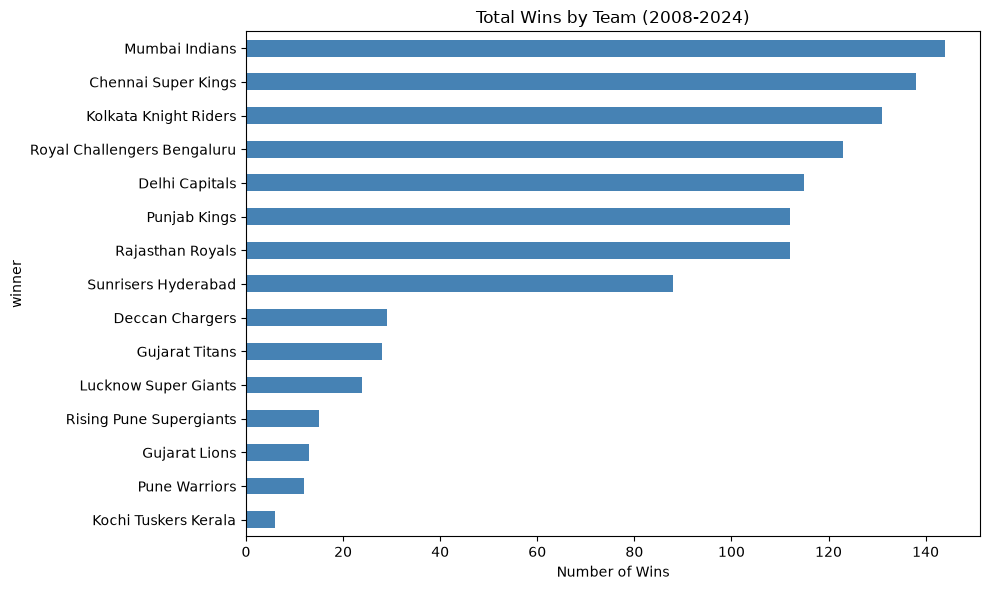

In [13]:
import matplotlib.pyplot as plt

win_counts = matches["winner"].value_counts()

plt.figure(figsize=(10, 6))
win_counts.sort_values().plot(kind="barh", color="steelblue")
plt.title("Total Wins by Team (2008-2024)")
plt.xlabel("Number of Wins")
plt.tight_layout()
plt.savefig("../Output/wins_by_team.png")
plt.show()

Toss winner also won the match: 50.6% of the time

Win rate by toss decision:
toss_decision
bat      45.268542
field    53.551136
Name: toss_winner_won_match, dtype: float64


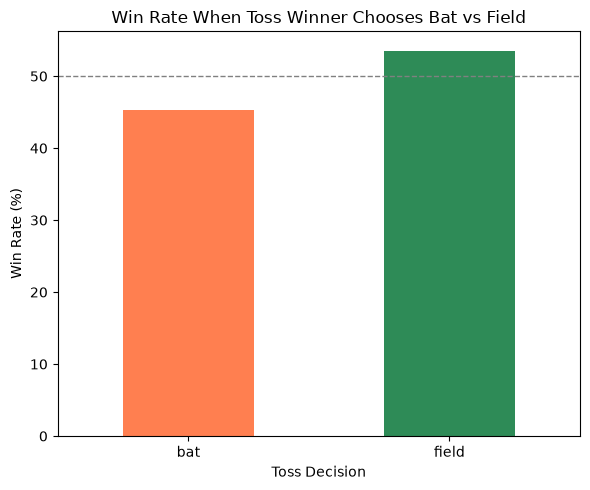

In [14]:
# Did the toss winner also win the match?
matches["toss_winner_won_match"] = matches["toss_winner"] == matches["winner"]

toss_win_rate = matches["toss_winner_won_match"].mean() * 100
print(f"Toss winner also won the match: {toss_win_rate:.1f}% of the time")

# Break it down by what they chose to do after winning the toss
toss_decision_impact = matches.groupby("toss_decision")["toss_winner_won_match"].mean() * 100
print("\nWin rate by toss decision:")
print(toss_decision_impact)

# Plot it
plt.figure(figsize=(6, 5))
toss_decision_impact.plot(kind="bar", color=["coral", "seagreen"])
plt.title("Win Rate When Toss Winner Chooses Bat vs Field")
plt.ylabel("Win Rate (%)")
plt.xlabel("Toss Decision")
plt.xticks(rotation=0)
plt.axhline(50, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.savefig("../Output/toss_impact.png")
plt.show()

In [18]:
from scipy.stats import chi2_contingency

# Build a contingency table: toss decision vs whether toss winner won
contingency = pd.crosstab(matches["toss_decision"], matches["toss_winner_won_match"])
print(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square p-value: {p_value:.4f}")

if p_value < 0.05:
    print("This difference is statistically significant.")
else:
    print("This difference is not statistically significant — could be due to chance.")

toss_winner_won_match  False  True 
toss_decision                      
bat                      214    177
field                    327    377

Chi-square p-value: 0.0104
This difference is statistically significant.


venue
Maharashtra Cricket Association Stadium       63.636364
Sharjah Cricket Stadium                       57.142857
Eden Gardens                                  55.844156
Wankhede Stadium, Mumbai                      55.555556
Dr DY Patil Sports Academy, Mumbai            55.000000
M Chinnaswamy Stadium                         53.846154
Sawai Mansingh Stadium                        53.191489
MA Chidambaram Stadium, Chepauk               52.083333
Sheikh Zayed Stadium                          51.724138
Feroz Shah Kotla                              51.666667
Wankhede Stadium                              50.684932
Narendra Modi Stadium, Ahmedabad              50.000000
Punjab Cricket Association Stadium, Mohali    45.714286
MA Chidambaram Stadium, Chepauk, Chennai      42.857143
Dubai International Cricket Stadium           39.130435
Rajiv Gandhi International Stadium, Uppal     34.693878
Name: toss_winner_won_match, dtype: float64


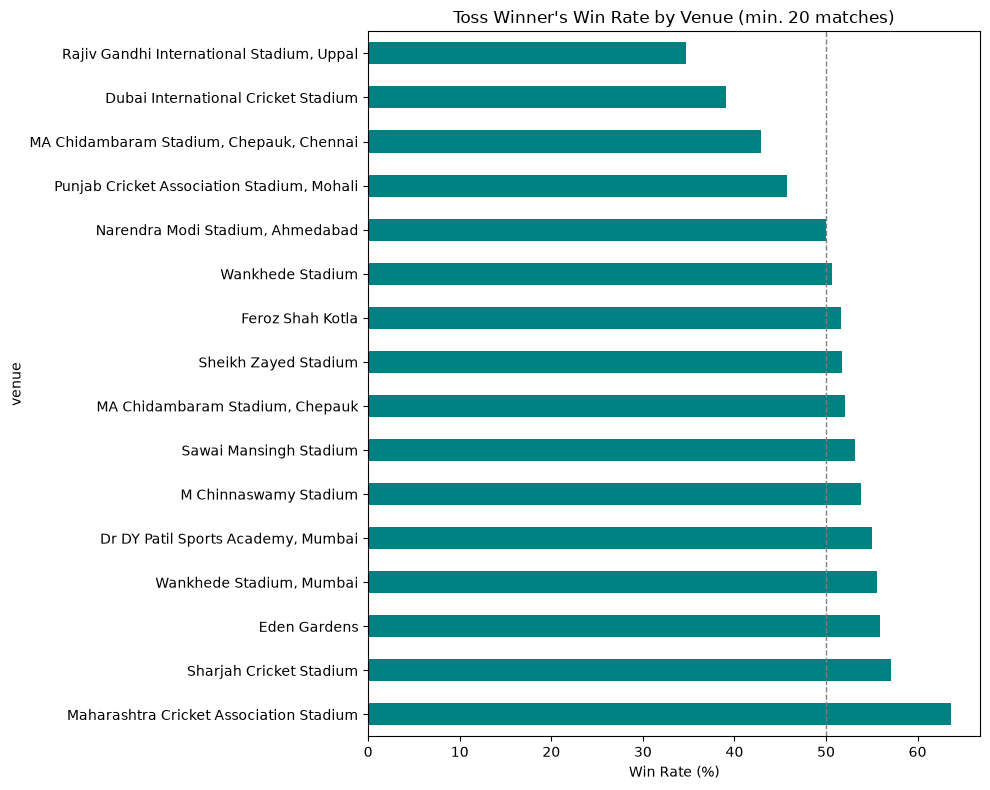

In [19]:
# Win rate for toss winner, broken down by venue (only venues with enough matches)
venue_counts = matches["venue"].value_counts()
common_venues = venue_counts[venue_counts >= 20].index

venue_toss = matches[matches["venue"].isin(common_venues)].groupby("venue")["toss_winner_won_match"].mean() * 100
venue_toss = venue_toss.sort_values(ascending=False)

print(venue_toss)

plt.figure(figsize=(10, 8))
venue_toss.plot(kind="barh", color="teal")
plt.title("Toss Winner's Win Rate by Venue (min. 20 matches)")
plt.xlabel("Win Rate (%)")
plt.axvline(50, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.savefig("../Output/toss_by_venue.png")
plt.show()

team_won
False    44.309025
True     50.100917
Name: powerplay_runs, dtype: float64


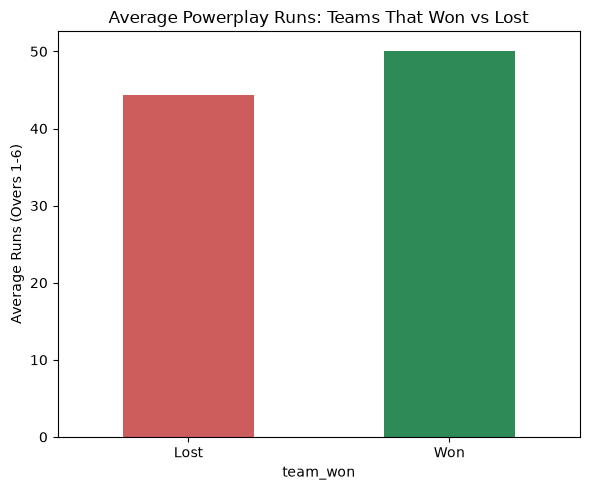

In [20]:
# Powerplay = overs 1-6. Calculate runs scored in powerplay per innings, per match
powerplay = deliveries[deliveries["over"] < 6]

powerplay_runs = powerplay.groupby(["match_id", "batting_team"])["total_runs"].sum().reset_index()
powerplay_runs.columns = ["match_id", "team", "powerplay_runs"]

# Merge with match winner info
powerplay_runs = powerplay_runs.merge(
    matches[["id", "winner"]], left_on="match_id", right_on="id"
)
powerplay_runs["team_won"] = powerplay_runs["team"] == powerplay_runs["winner"]

# Compare average powerplay runs: winners vs losers
avg_by_outcome = powerplay_runs.groupby("team_won")["powerplay_runs"].mean()
print(avg_by_outcome)

plt.figure(figsize=(6, 5))
avg_by_outcome.plot(kind="bar", color=["indianred", "seagreen"])
plt.title("Average Powerplay Runs: Teams That Won vs Lost")
plt.ylabel("Average Runs (Overs 1-6)")
plt.xticks([0, 1], ["Lost", "Won"], rotation=0)
plt.tight_layout()
plt.savefig("../Output/powerplay_impact.png")
plt.show()

In [21]:
from scipy.stats import ttest_ind

won_pp = powerplay_runs[powerplay_runs["team_won"] == True]["powerplay_runs"]
lost_pp = powerplay_runs[powerplay_runs["team_won"] == False]["powerplay_runs"]

t_stat, p_value = ttest_ind(won_pp, lost_pp)
print(f"T-test p-value: {p_value:.6f}")

if p_value < 0.05:
    print("The powerplay run difference is statistically significant.")
else:
    print("Not statistically significant — could be due to chance.")

T-test p-value: 0.000000
The powerplay run difference is statistically significant.


# IPL Match Analysis: What Drives a Win?

## Project Overview
This project analyzes IPL match data (2008–2024) to understand which factors — toss decisions, venue, and early-innings performance — are actually linked to winning a match. The goal is to move beyond simple "who won the most" trivia and find patterns that could inform in-game strategy.

## Dataset
- **Source:** Cricsheet, via Kaggle ("IPL Complete Dataset 2008–2024")
- **Size:** 1,095 matches, 260,920 ball-by-ball deliveries
- **Cleaning:** Standardized team names across franchise renames (e.g., Delhi Daredevils → Delhi Capitals)

## Key Findings

**1. Team dominance**
Mumbai Indians and Chennai Super Kings have the most wins in IPL history, well ahead of the rest of the league.

**2. Toss decision matters**
Teams that win the toss and choose to field first win more often than those who bat first (statistically significant, chi-square test, p = 0.0104).

**3. The toss advantage depends on venue**
This effect isn't uniform. At some venues, the toss winner has a clear edge; at others (e.g., MA Chidambaram Stadium, Chepauk), the toss winner actually wins *less* than half the time.

**4. Powerplay performance strongly predicts the outcome**
Teams that score more runs in the first 6 overs (powerplay) are significantly more likely to win the match (t-test, p < 0.000001). Winning teams average ~50 runs in the powerplay vs. ~44 for losing teams.

## Recommendations
- Captains should generally lean toward fielding first after winning the toss — but check the venue's historical pattern first, since the advantage varies by ground.
- Teams should prioritize an aggressive powerplay strategy, since early scoring rate is one of the strongest predictors of winning in this data.

## Limitations
- This analysis is correlational, not causal — a fast powerplay may reflect a stronger team overall, not just a good tactic.
- Toss and venue effects may be influenced by other factors not modeled here (e.g., dew, pitch reports, team strength).

## Next Steps
A natural extension is a machine learning model that predicts match winner using toss, venue, and powerplay stats as features.